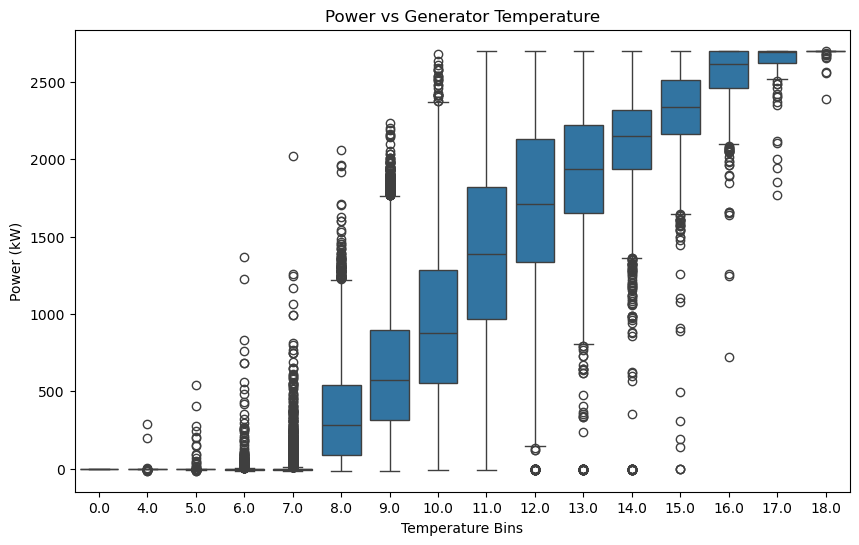

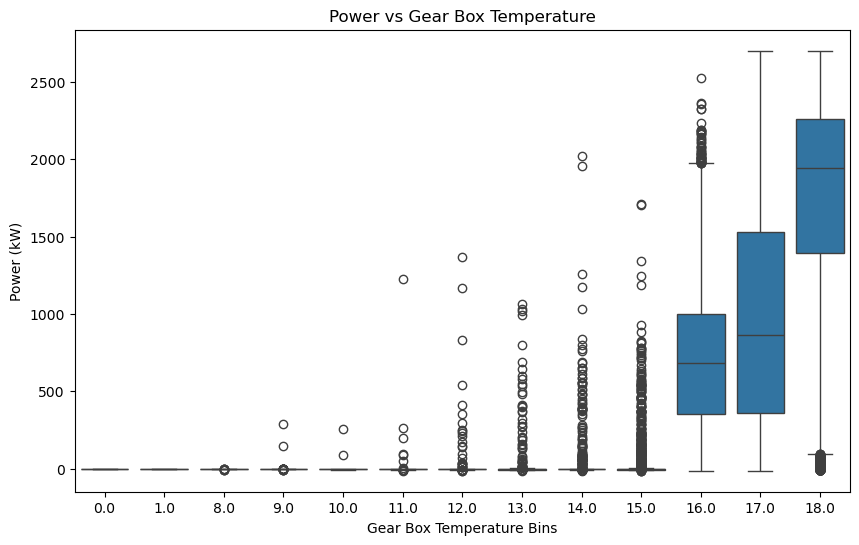

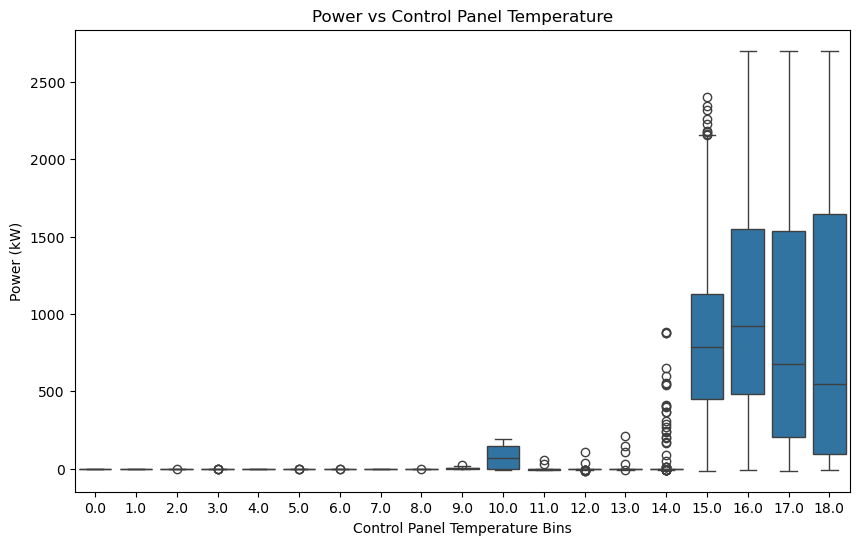

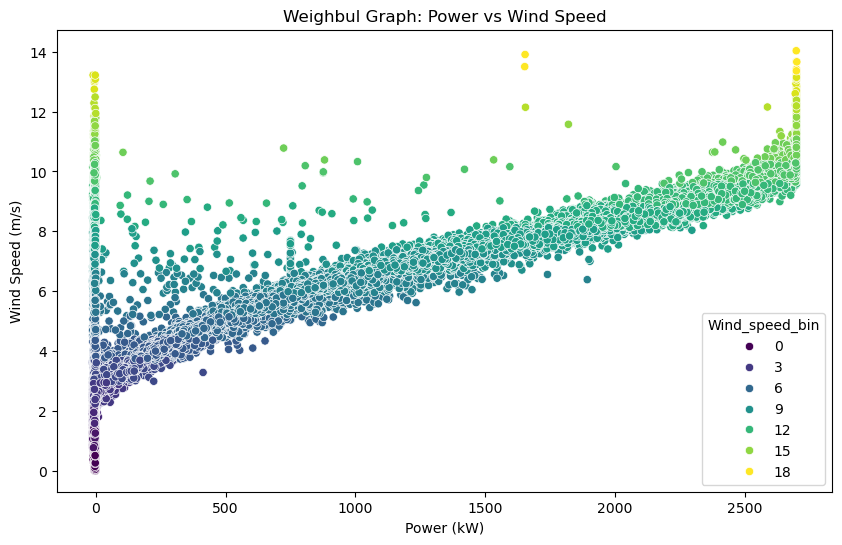

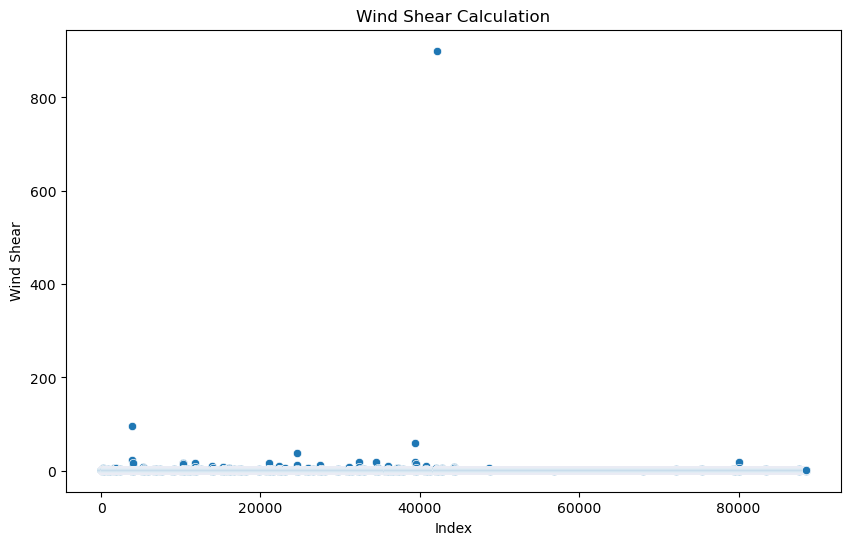

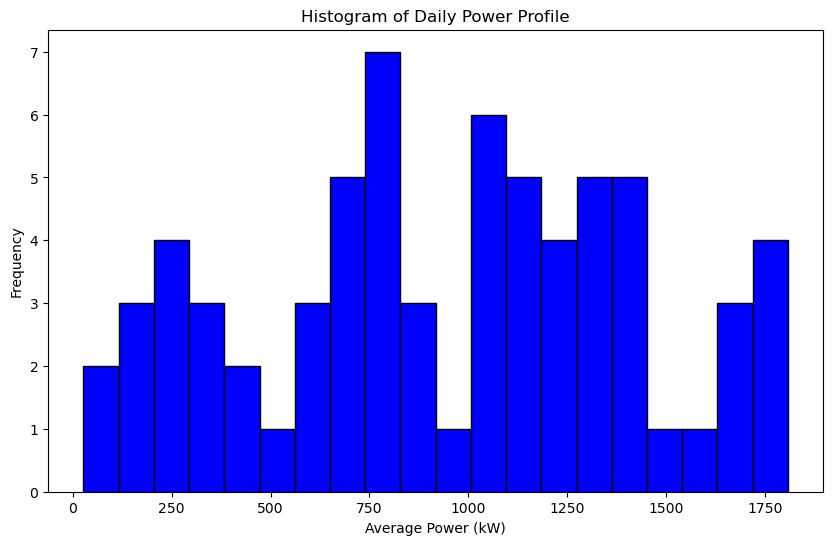

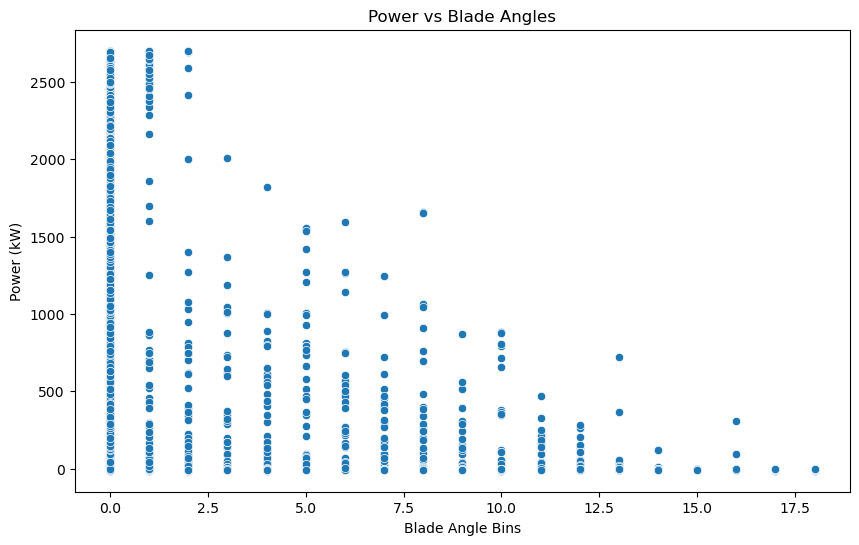

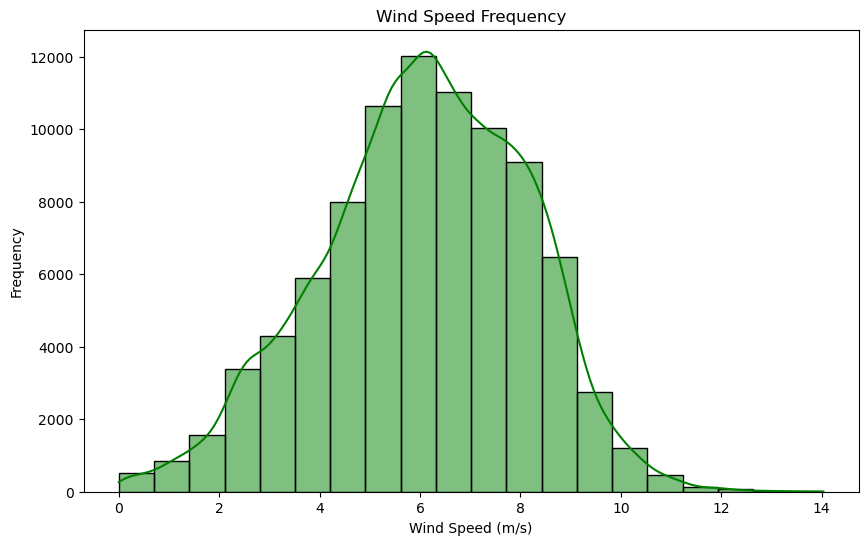

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (change the path to your file)
# If it's an Excel file: 
df = pd.read_excel("Wind Data - Dec - Jan.xlsx")
# If it's a CSV file: 
#df = pd.read_csv("your_file.csv")

# Define the binning function
def binning(df, column_name, bins):
    return pd.cut(df[column_name], bins=bins, labels=False)

# Define the bin edges for each relevant parameter
# Modify these edges based on the range and distribution of your data
power_bins = np.linspace(df['P_ACT_Avg'].min(), df['P_ACT_Avg'].max(), 20)
temp_bins = np.linspace(df['T_GEN_1_Avg'].min(), df['T_GEN_1_Avg'].max(), 20)
gear_temp_bins = np.linspace(df['T_GEAR_Avg'].min(), df['T_GEAR_Avg'].max(), 20)
control_temp_bins = np.linspace(df['AI_In_ControlBoxTempA1_Avg'].min(), df['AI_In_ControlBoxTempA1_Avg'].max(), 20)
wind_speed_bins = np.linspace(df['V_WIN_Avg'].min(), df['V_WIN_Avg'].max(), 20)
blade_angle_bins = np.linspace(df['BL1_ACT_Avg'].min(), df['BL1_ACT_Avg'].max(), 20)

# Apply binning
df['Power_bin'] = binning(df, 'P_ACT_Avg', power_bins)
df['Temp_bin'] = binning(df, 'T_GEN_1_Avg', temp_bins)
df['Gear_temp_bin'] = binning(df, 'T_GEAR_Avg', gear_temp_bins)
df['Control_temp_bin'] = binning(df, 'AI_In_ControlBoxTempA1_Avg', control_temp_bins)
df['Wind_speed_bin'] = binning(df, 'V_WIN_Avg', wind_speed_bins)
df['Blade_angle_bin'] = binning(df, 'BL1_ACT_Avg', blade_angle_bins)

# Plotting Power vs Temperature (T_GEN_1_Avg)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Generator Temperature')
plt.xlabel('Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Plotting Power vs Gear Box Temperature
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gear_temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Gear Box Temperature')
plt.xlabel('Gear Box Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Plotting Power vs Control Panel Temperature
plt.figure(figsize=(10, 6))
sns.boxplot(x='Control_temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Control Panel Temperature')
plt.xlabel('Control Panel Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Weighbul graph (you may need to modify based on your requirement)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['P_ACT_Avg'], y=df['V_WIN_Avg'], hue=df['Wind_speed_bin'], palette='viridis')
plt.title('Weighbul Graph: Power vs Wind Speed')
plt.xlabel('Power (kW)')
plt.ylabel('Wind Speed (m/s)')
plt.show()

# Wind Shear calculation (assuming it’s the ratio of wind speeds at two heights)
df['Wind_shear'] = df['V_WIN_Avg'] / df['V_WIN_Avg'].shift(1)  # Modify this based on your wind shear formula

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.index, y=df['Wind_shear'])
plt.title('Wind Shear Calculation')
plt.xlabel('Index')
plt.ylabel('Wind Shear')
plt.show()

# Histogram for daily profile (assuming data contains daily information)
df['Date'] = pd.to_datetime(df['Timestamp'])
df['Day'] = df['Date'].dt.date
df_daily = df.groupby('Day').agg({'P_ACT_Avg': 'mean'})

plt.figure(figsize=(10, 6))
plt.hist(df_daily['P_ACT_Avg'], bins=20, color='blue', edgecolor='black')
plt.title('Histogram of Daily Power Profile')
plt.xlabel('Average Power (kW)')
plt.ylabel('Frequency')
plt.show()

# Power vs Blade Angles (BL1_ACT_Avg)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Blade_angle_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Blade Angles')
plt.xlabel('Blade Angle Bins')
plt.ylabel('Power (kW)')
plt.show()

# Wind Speed Frequency graph
plt.figure(figsize=(10, 6))
sns.histplot(df['V_WIN_Avg'], bins=20, kde=True, color='green')
plt.title('Wind Speed Frequency')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.show()


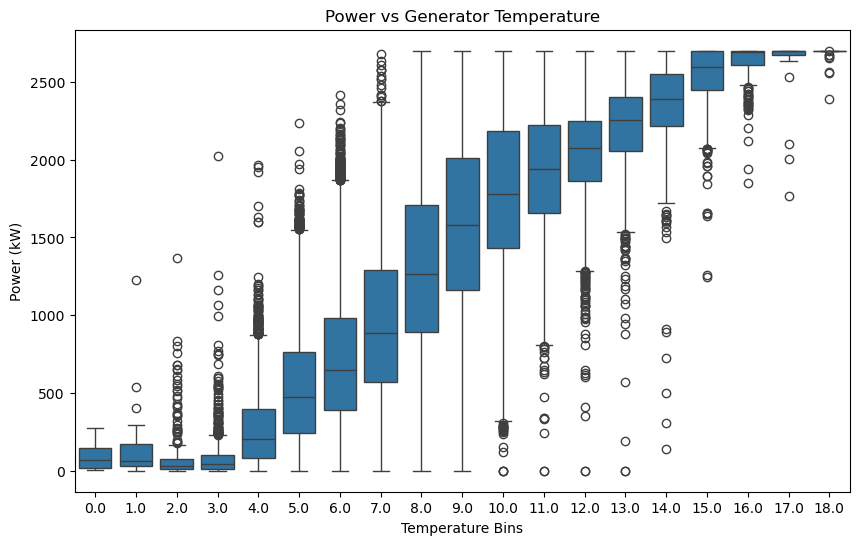

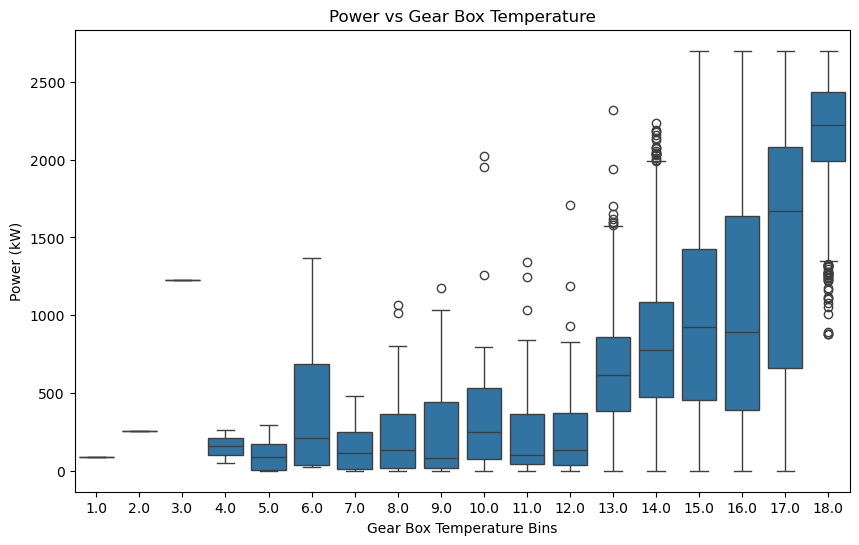

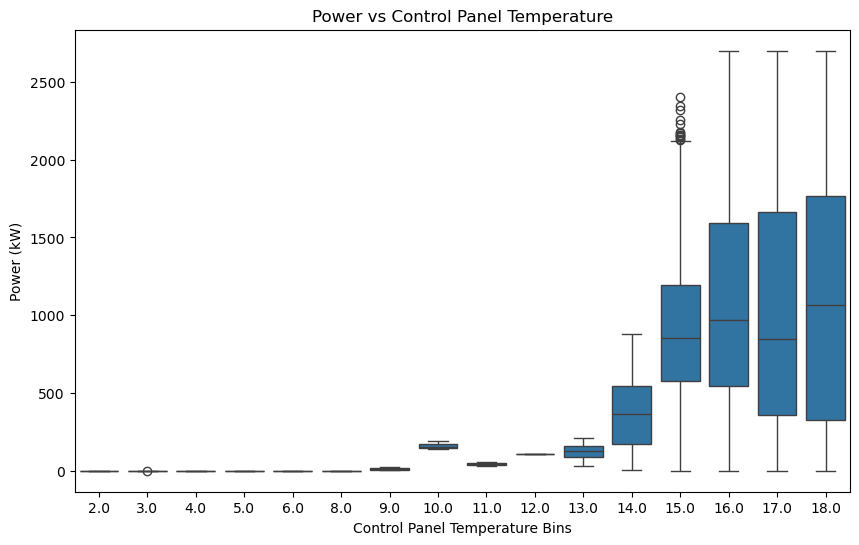

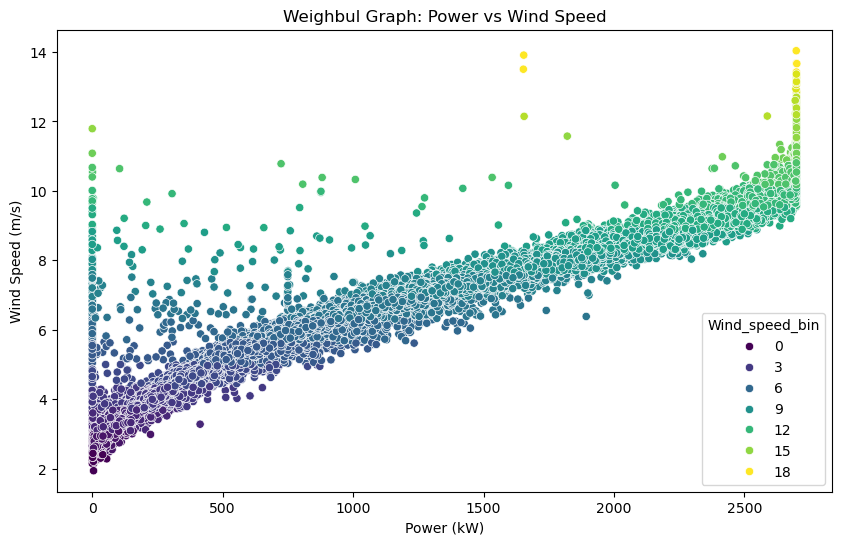

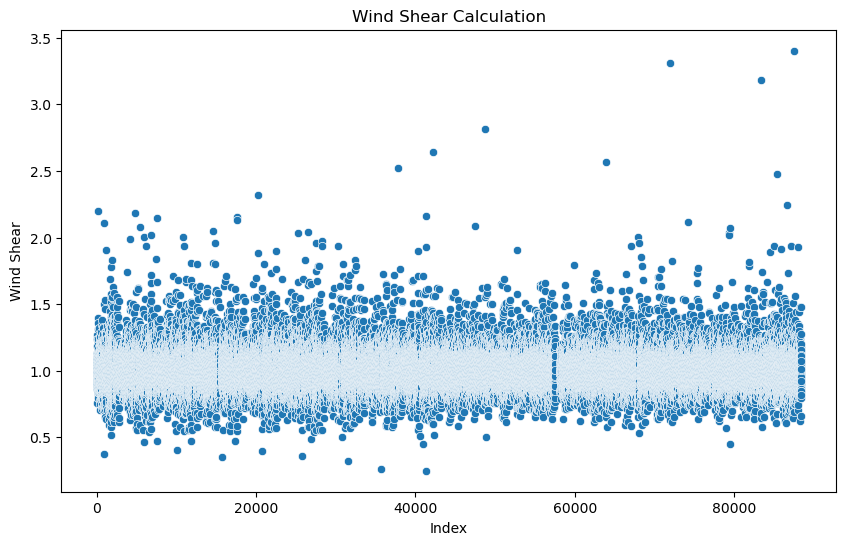

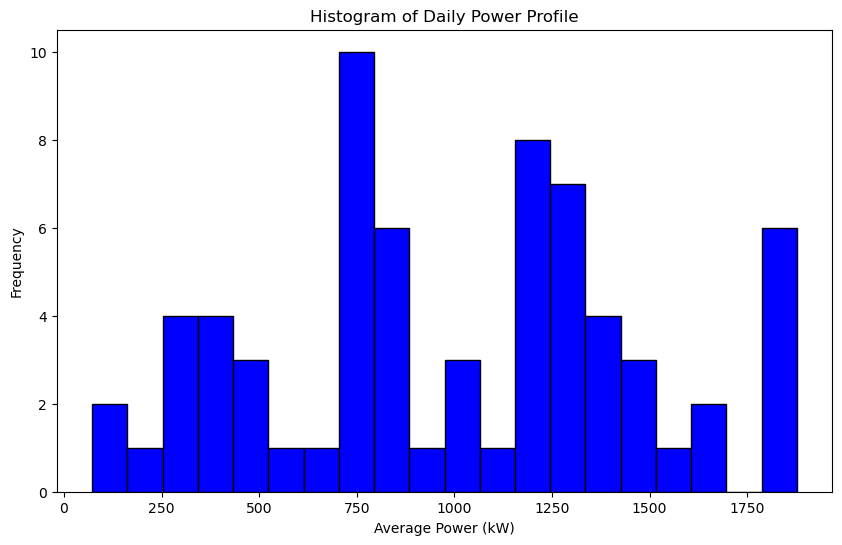

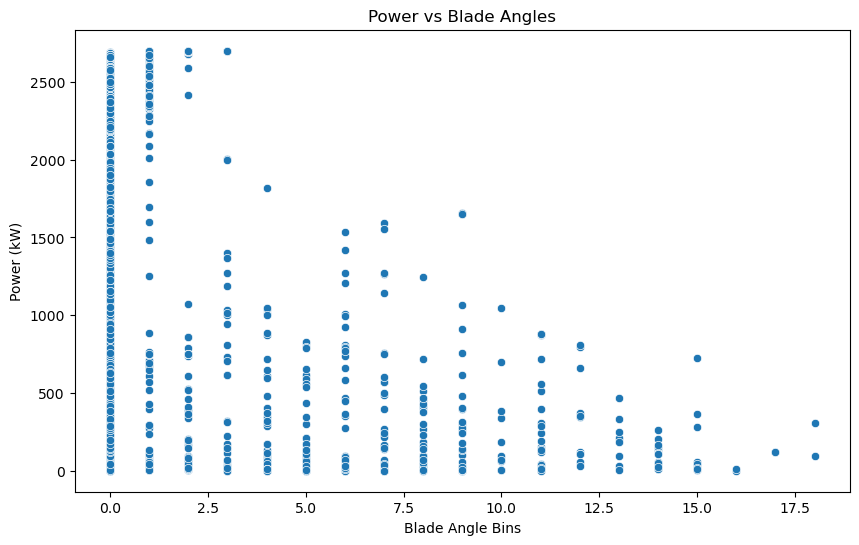

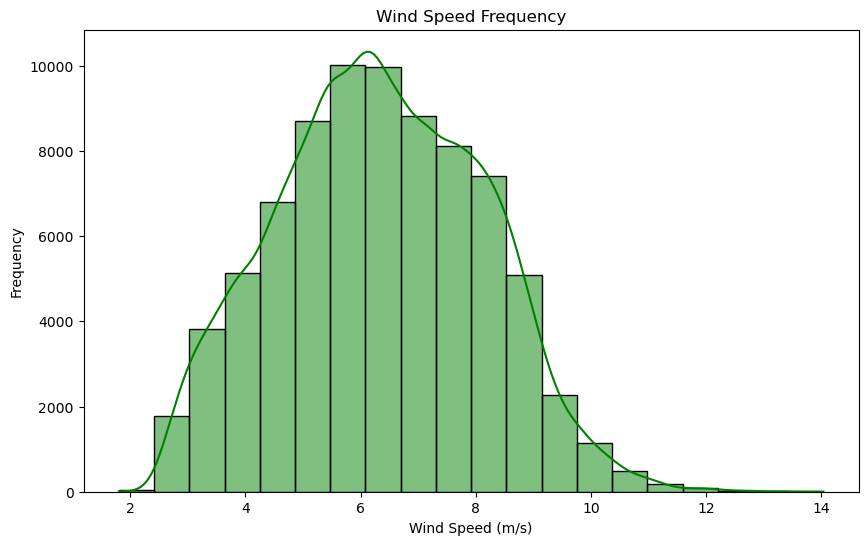

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (change the path to your file)
df = pd.read_excel("Wind Data - Dec - Jan.xlsx")  # For Excel files
# df = pd.read_csv("your_file.csv")  # For CSV files

# Remove anomalies: Filter out rows where P_ACT_Avg is negative or adjacent rows have zero values
df = df[df['P_ACT_Avg'] >= 0]  # Remove rows with negative power values
df = df[(df['P_ACT_Avg'] != 0) & (df['P_ACT_Avg'].shift(-1) != 0) & (df['P_ACT_Avg'].shift(1) != 0)]

# Define the binning function
def binning(df, column_name, bins):
    return pd.cut(df[column_name], bins=bins, labels=False)

# Define the bin edges for each relevant parameter
# Modify these edges based on the range and distribution of your data
power_bins = np.linspace(df['P_ACT_Avg'].min(), df['P_ACT_Avg'].max(), 20)
temp_bins = np.linspace(df['T_GEN_1_Avg'].min(), df['T_GEN_1_Avg'].max(), 20)
gear_temp_bins = np.linspace(df['T_GEAR_Avg'].min(), df['T_GEAR_Avg'].max(), 20)
control_temp_bins = np.linspace(df['AI_In_ControlBoxTempA1_Avg'].min(), df['AI_In_ControlBoxTempA1_Avg'].max(), 20)
wind_speed_bins = np.linspace(df['V_WIN_Avg'].min(), df['V_WIN_Avg'].max(), 20)
blade_angle_bins = np.linspace(df['BL1_ACT_Avg'].min(), df['BL1_ACT_Avg'].max(), 20)

# Apply binning
df['Power_bin'] = binning(df, 'P_ACT_Avg', power_bins)
df['Temp_bin'] = binning(df, 'T_GEN_1_Avg', temp_bins)
df['Gear_temp_bin'] = binning(df, 'T_GEAR_Avg', gear_temp_bins)
df['Control_temp_bin'] = binning(df, 'AI_In_ControlBoxTempA1_Avg', control_temp_bins)
df['Wind_speed_bin'] = binning(df, 'V_WIN_Avg', wind_speed_bins)
df['Blade_angle_bin'] = binning(df, 'BL1_ACT_Avg', blade_angle_bins)

# Plotting Power vs Temperature (T_GEN_1_Avg)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Generator Temperature')
plt.xlabel('Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Plotting Power vs Gear Box Temperature
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gear_temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Gear Box Temperature')
plt.xlabel('Gear Box Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Plotting Power vs Control Panel Temperature
plt.figure(figsize=(10, 6))
sns.boxplot(x='Control_temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Control Panel Temperature')
plt.xlabel('Control Panel Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Weighbul graph (you may need to modify based on your requirement)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['P_ACT_Avg'], y=df['V_WIN_Avg'], hue=df['Wind_speed_bin'], palette='viridis')
plt.title('Weighbul Graph: Power vs Wind Speed')
plt.xlabel('Power (kW)')
plt.ylabel('Wind Speed (m/s)')
plt.show()

# Wind Shear calculation (assuming it’s the ratio of wind speeds at two heights)
df['Wind_shear'] = df['V_WIN_Avg'] / df['V_WIN_Avg'].shift(1)  # Modify this based on your wind shear formula

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.index, y=df['Wind_shear'])
plt.title('Wind Shear Calculation')
plt.xlabel('Index')
plt.ylabel('Wind Shear')
plt.show()

# Histogram for daily profile (assuming data contains daily information)
df['Date'] = pd.to_datetime(df['Timestamp'])
df['Day'] = df['Date'].dt.date
df_daily = df.groupby('Day').agg({'P_ACT_Avg': 'mean'})

plt.figure(figsize=(10, 6))
plt.hist(df_daily['P_ACT_Avg'], bins=20, color='blue', edgecolor='black')
plt.title('Histogram of Daily Power Profile')
plt.xlabel('Average Power (kW)')
plt.ylabel('Frequency')
plt.show()

# Power vs Blade Angles (BL1_ACT_Avg)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Blade_angle_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Blade Angles')
plt.xlabel('Blade Angle Bins')
plt.ylabel('Power (kW)')
plt.show()

# Wind Speed Frequency graph
plt.figure(figsize=(10, 6))
sns.histplot(df['V_WIN_Avg'], bins=20, kde=True, color='green')
plt.title('Wind Speed Frequency')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.show()


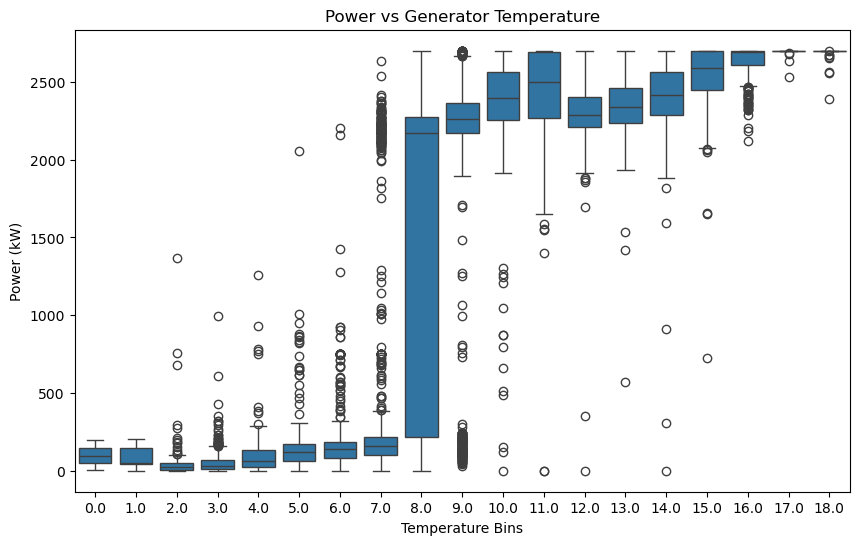

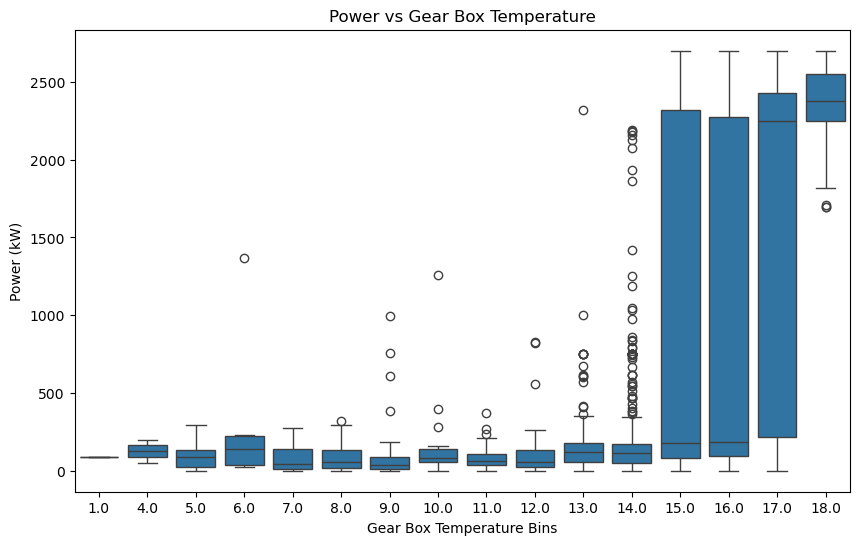

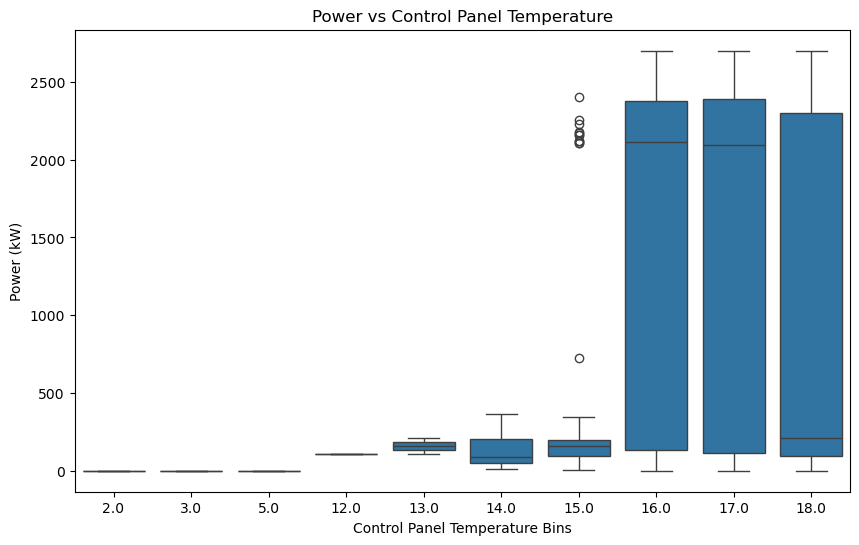

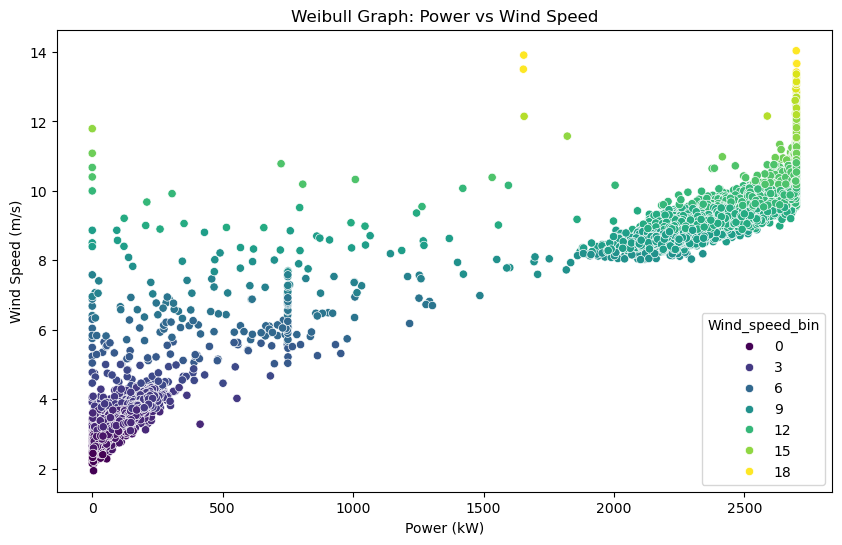

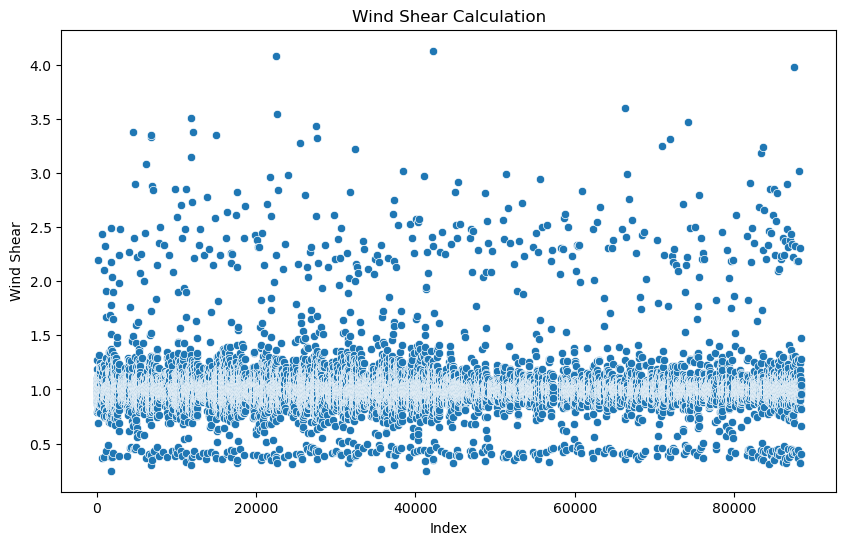

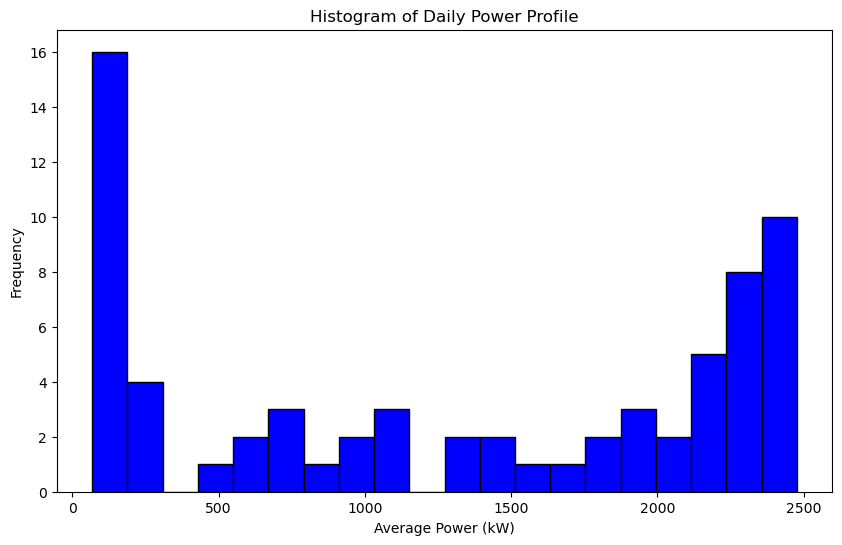

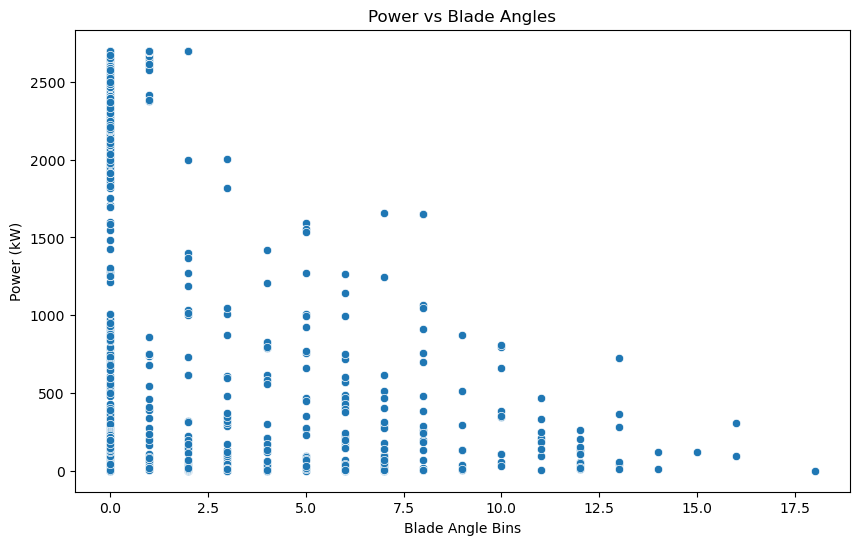

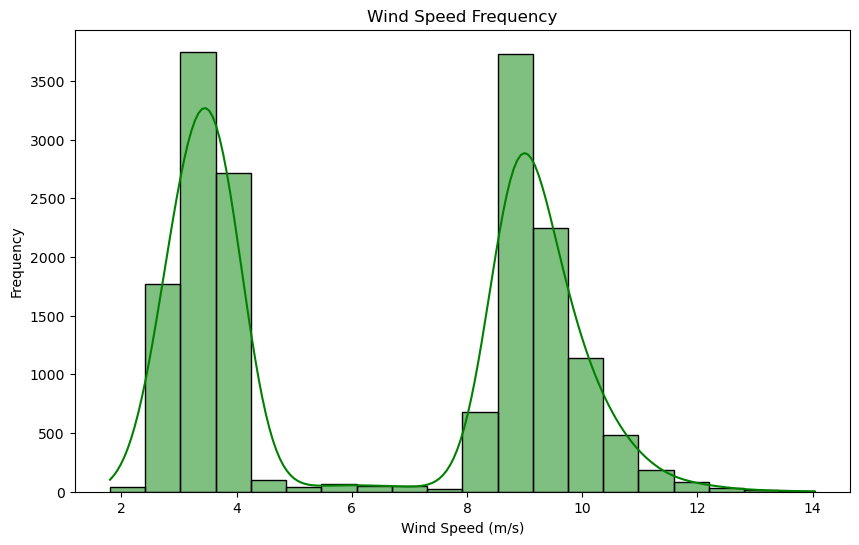

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (change the path to your file)
# If it's an Excel file: 
df = pd.read_excel("Wind Data - Dec - Jan.xlsx")
# If it's a CSV file: 
# df = pd.read_csv("your_file.csv")

# Remove anomalies: negative values or adjacent rows with zero values
columns_to_check = ['P_ACT_Avg', 'T_GEN_1_Avg', 'T_GEAR_Avg', 'AI_In_ControlBoxTempA1_Avg', 'V_WIN_Avg', 'BL1_ACT_Avg']

for col in columns_to_check:
    df = df[(df[col] >= 0) & (df[col].shift(-1) != 0) & (df[col].shift(1) != 0)]

# Define the binning function
def binning(df, column_name, bins):
    return pd.cut(df[column_name], bins=bins, labels=False)

# Define the bin edges for each relevant parameter
power_bins = np.linspace(df['P_ACT_Avg'].min(), df['P_ACT_Avg'].max(), 20)
temp_bins = np.linspace(df['T_GEN_1_Avg'].min(), df['T_GEN_1_Avg'].max(), 20)
gear_temp_bins = np.linspace(df['T_GEAR_Avg'].min(), df['T_GEAR_Avg'].max(), 20)
control_temp_bins = np.linspace(df['AI_In_ControlBoxTempA1_Avg'].min(), df['AI_In_ControlBoxTempA1_Avg'].max(), 20)
wind_speed_bins = np.linspace(df['V_WIN_Avg'].min(), df['V_WIN_Avg'].max(), 20)
blade_angle_bins = np.linspace(df['BL1_ACT_Avg'].min(), df['BL1_ACT_Avg'].max(), 20)

# Apply binning
df['Power_bin'] = binning(df, 'P_ACT_Avg', power_bins)
df['Temp_bin'] = binning(df, 'T_GEN_1_Avg', temp_bins)
df['Gear_temp_bin'] = binning(df, 'T_GEAR_Avg', gear_temp_bins)
df['Control_temp_bin'] = binning(df, 'AI_In_ControlBoxTempA1_Avg', control_temp_bins)
df['Wind_speed_bin'] = binning(df, 'V_WIN_Avg', wind_speed_bins)
df['Blade_angle_bin'] = binning(df, 'BL1_ACT_Avg', blade_angle_bins)

# Plotting Power vs Temperature (T_GEN_1_Avg)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Generator Temperature')
plt.xlabel('Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Plotting Power vs Gear Box Temperature
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gear_temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Gear Box Temperature')
plt.xlabel('Gear Box Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Plotting Power vs Control Panel Temperature
plt.figure(figsize=(10, 6))
sns.boxplot(x='Control_temp_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Control Panel Temperature')
plt.xlabel('Control Panel Temperature Bins')
plt.ylabel('Power (kW)')
plt.show()

# Weibull graph (scatter plot of Power vs Wind Speed)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['P_ACT_Avg'], y=df['V_WIN_Avg'], hue=df['Wind_speed_bin'], palette='viridis')
plt.title('Weibull Graph: Power vs Wind Speed')
plt.xlabel('Power (kW)')
plt.ylabel('Wind Speed (m/s)')
plt.show()

# Wind Shear calculation (assuming it’s the ratio of wind speeds at two heights)
df['Wind_shear'] = df['V_WIN_Avg'] / df['V_WIN_Avg'].shift(1)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.index, y=df['Wind_shear'])
plt.title('Wind Shear Calculation')
plt.xlabel('Index')
plt.ylabel('Wind Shear')
plt.show()

# Histogram for daily profile
# Ensure the correct format for your Timestamp column
df['Date'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
#df['Date'] = pd.to_datetime(df['Timestamp'])
df['Day'] = df['Date'].dt.date
df_daily = df.groupby('Day').agg({'P_ACT_Avg': 'mean'})

plt.figure(figsize=(10, 6))
plt.hist(df_daily['P_ACT_Avg'], bins=20, color='blue', edgecolor='black')
plt.title('Histogram of Daily Power Profile')
plt.xlabel('Average Power (kW)')
plt.ylabel('Frequency')
plt.show()

# Power vs Blade Angles (BL1_ACT_Avg)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Blade_angle_bin', y='P_ACT_Avg', data=df)
plt.title('Power vs Blade Angles')
plt.xlabel('Blade Angle Bins')
plt.ylabel('Power (kW)')
plt.show()

# Wind Speed Frequency graph
plt.figure(figsize=(10, 6))
sns.histplot(df['V_WIN_Avg'], bins=20, kde=True, color='green')
plt.title('Wind Speed Frequency')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.show()


In [15]:
df['Date'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M', errors='coerce')
#df['Date'] = pd.to_datetime(df['Timestamp'])
df['Day'] = df['Date'].dt.date
df_daily = df.groupby('Day').agg({'P_ACT_Avg': 'mean'})

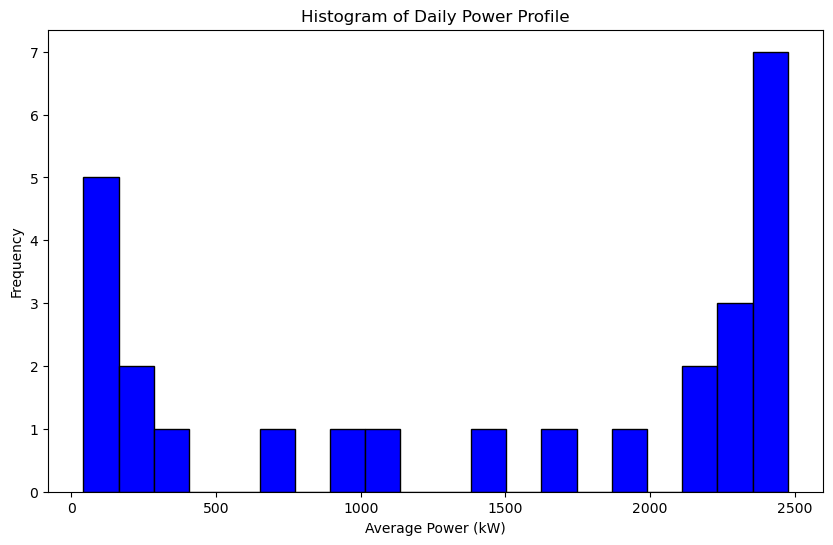

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df_daily['P_ACT_Avg'], bins=20, color='blue', edgecolor='black')
plt.title('Histogram of Daily Power Profile')
plt.xlabel('Average Power (kW)')
plt.ylabel('Frequency')
plt.show()